# Ahora repetimos todo el analisis que realizamos en principio para nuestro set de datos ya tratado

In [ ]:
data_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 35 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   edad                           20000 non-null  float64
 1   ingreso_mensual                20000 non-null  float64
 2   gasto_mensual                  20000 non-null  float64
 3   deuda_total                    20000 non-null  float64
 4   score_crediticio               20000 non-null  float64
 5   antiguedad_meses               20000 non-null  float64
 6   frecuencia_compra              20000 non-null  float64
 7   ultima_compra_dias             20000 non-null  float64
 8   num_productos                  20000 non-null  float64
 9   ratio_deuda                    20000 non-null  float64
 10  genero_Femenino                20000 non-null  float64
 11  genero_Masculino               20000 non-null  float64
 12  genero_Otro                    20000 non-null 

In [ ]:
data_clean.isna().sum()

,0
edad,0
ingreso_mensual,0
gasto_mensual,0
deuda_total,0
score_crediticio,0
antiguedad_meses,0
frecuencia_compra,0
ultima_compra_dias,0
num_productos,0
ratio_deuda,0


In [ ]:
data_clean.duplicated().sum()

np.int64(0)

In [ ]:
data_clean.describe()

,edad,ingreso_mensual,gasto_mensual,deuda_total,score_crediticio,antiguedad_meses,frecuencia_compra,ultima_compra_dias,num_productos,ratio_deuda,...,dia_semana_registro_Martes,dia_semana_registro_Miercoles,dia_semana_registro_Sabado,dia_semana_registro_Viernes,tiene_tarjeta_credito_0,tiene_tarjeta_credito_1,uso_app,tipo_plan,riesgo_financiero,abandono
count,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,...,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000
mean,0.500272,0.496368,0.499379,0.490913,0.502989,0.501879,0.497597,0.498230,0.499025,0.371217,...,0.143350,0.146700,0.140150,0.141350,0.499200,0.500800,0.995350,1.011050,0.921150,0.396750
std,0.319244,0.267560,0.269897,0.275429,0.268297,0.317326,0.303375,0.315754,0.352596,0.254329,...,0.350438,0.353815,0.347151,0.348391,0.500012,0.500012,0.818695,0.814408,0.269511,0.489236
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.218182,0.306298,0.305226,0.286371,0.314042,0.226415,0.222222,0.222561,0.250000,0.188698,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000
50%,0.490909,0.496368,0.499379,0.489961,0.502989,0.509434,0.500000,0.493902,0.500000,0.339265,...,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,1.000000,0.000000
75%,0.781818,0.684991,0.690068,0.688693,0.692701,0.783019,0.777778,0.777439,0.750000,0.493689,...,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,2.000000,2.000000,1.000000,1.000000
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,2.000000,2.000000,1.000000,1.000000


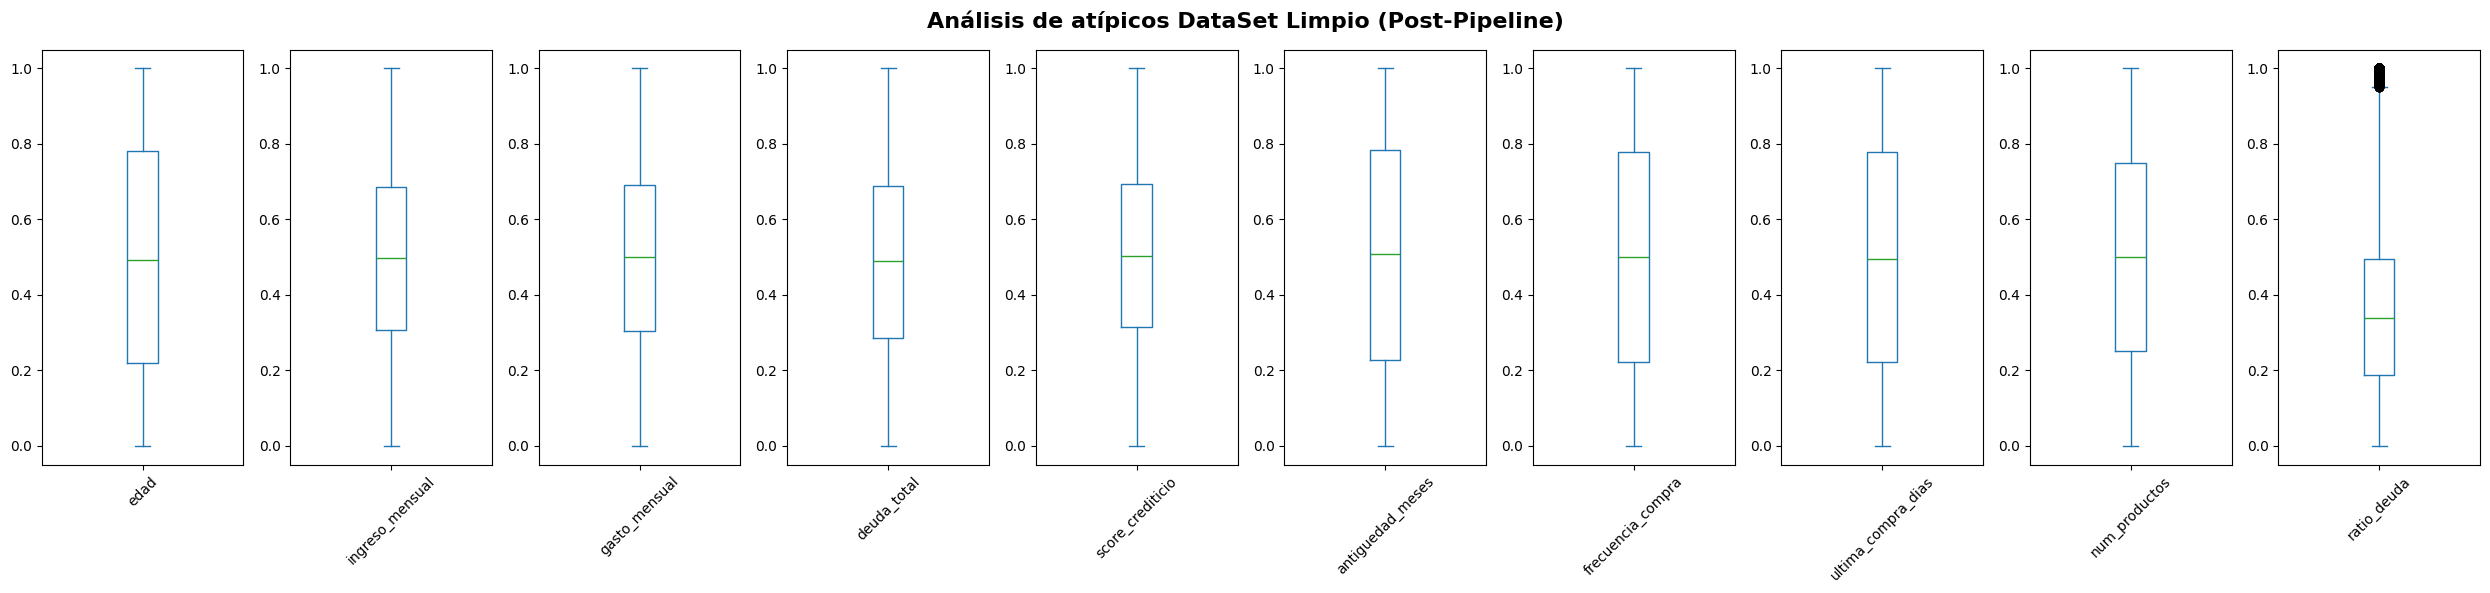

In [ ]:
# Tomamos las columnas numericas que definimos para el Pipeline
revision_atipicos_dataClean = data_clean[numeric_features]

fig, axes = plt.subplots(1, len(numeric_features), figsize=(25, 6))
axes = axes.flatten() # convierte la matriz de ejes en un vector

# 3. Iteramos sobre las columnas del nuevo dataframe limpio
for i, col in enumerate(numeric_features):
    data_clean[col].plot(kind='box', ax=axes[i])
    axes[i].tick_params(axis="x", labelrotation=45)

plt.suptitle("Análisis de atípicos DataSet Limpio (Post-Pipeline)", fontsize=16, fontweight="bold")
plt.tight_layout()

plt.show()

Como pueden observar en los gráficos de validación finales, todas nuestras variables numéricas quedaron perfectamente estandarizadas entre 0 y 1. Sin embargo, hay un detalle interesante en la variable que creamos, el ratio_deuda: a pesar de haber pasado por el pipeline, sigue mostrando valores atípicos en el boxplot.


Al analizar este comportamiento, identificamos que ocurre por dos motivos, y decidimos mantenerlo así de forma estratégica:

La justificación técnica: Esto es producto de un choque matemático. Nuestro Winsorizer actuó correctamente poniendo un techo estadístico al 5% de los datos más extremos. Pero, como esta variable es la división entre la deuda y los ingresos de los clientes, tiene una distribución tan asimétrica que ese 'techo' sigue siendo lo suficientemente alto como para que el gráfico de Boxplot lo dibuje como un atípico. La variable está contenida y no romperá el modelo, pero sigue mostrando sus extremos.

La justificación de negocio (El valor real): Lejos de ser un error, decidimos conservar esta distribución porque realmente aporta al análisis. Esos puntos atípicos representan exactamente a los clientes que el negocio necesita detectar: personas que están asfixiadas económicamente. Al mantener este comportamiento, le estamos entregando al futuro modelo de Machine Learning una señal clarísima para predecir qué clientes son los más propensos a cancelar el servicio por problemas de dinero.

# factores que aumentan la ida de un cliente

In [ ]:
"""
Los algoritmos de Machine Learning requieren que todas las variables sean numéricas.
Por ello, nuestro Pipeline transformó las categorías de texto en múltiples columnas
binarias (One-Hot Encoding) y escalas numéricas (Ordinal Encoding). Sin embargo,
para el Análisis Bivariado y la generación de gráficos (EDA Post-Pipeline), los
humanos necesitamos leer las etiquetas originales ('Norte', 'Basico', 'Femenino').

Este bloque realiza una "ingeniería inversa temporal" exclusiva para graficar,
garantizando que visualicemos los datos ya limpios (sin nulos y con outliers
tratados) pero con etiquetas legibles.

MECÁNICA TÉCNICA (Cómo funciona):
1. .copy():
   Crea 'df_plot'. Es crucial para aislar esta transformación; asegura que
   'data_clean' siga siendo una matriz puramente matemática lista para el modelo.

2. .idxmax(axis=1) y .str.replace() [Para One-Hot Encoding]:
   Las variables 'region' y 'genero' están divididas en varias columnas de 0s y 1s.
   - `idxmax(axis=1)` busca fila por fila (horizontalmente) y devuelve el NOMBRE de
     la columna que contiene el valor máximo (es decir, el 1).
   - `.str.replace()` limpia ese nombre (ej. transforma 'region_Norte' a 'Norte'),
     reconstruyendo la columna original en un solo paso vectorizado.

3. .map() [Para Ordinal Encoding]:
   La variable 'tipo_plan' fue transformada a 0.0, 1.0 y 2.0.
   Usando un diccionario (`mapa_plan`), la función `.map()` busca cada número y
   lo sustituye directamente por su etiqueta jerárquica de texto correspondiente.
"""

# Creamos una copia específica para graficar sin alterar data_clean
df_plot = data_clean.copy()

# A. Reconstruir 'region' desde las columnas One-Hot usando idxmax
cols_region = ['region_Centro', 'region_Norte', 'region_Sur']
df_plot['region'] = df_plot[cols_region].idxmax(axis=1).str.replace('region_', '')

# B. Reconstruir 'genero'
cols_genero = ['genero_Femenino', 'genero_Masculino', 'genero_Otro']
df_plot['genero'] = df_plot[cols_genero].idxmax(axis=1).str.replace('genero_', '')

# C. Reconstruir 'tipo_plan' a texto
mapa_plan = {0.0: 'Basico', 1.0: 'Estandar', 2.0: 'Premium'}
df_plot['tipo_plan_nom'] = df_plot['tipo_plan'].map(mapa_plan)




=== Análisis Bivariado Clean: Tasa de Abandono y Gasto Medio por Región y Plan ===


,region,tipo_plan_nom,abandono,gasto_mensual
0,Centro,Basico,0.475113,0.491986
1,Centro,Estandar,0.363920,0.499983
2,Centro,Premium,0.363057,0.501482
3,Norte,Basico,0.449137,0.490618
4,Norte,Estandar,0.359347,0.502699
5,Norte,Premium,0.348940,0.518399
6,Sur,Basico,0.460919,0.498089
7,Sur,Estandar,0.381349,0.498111
8,Sur,Premium,0.374671,0.492756


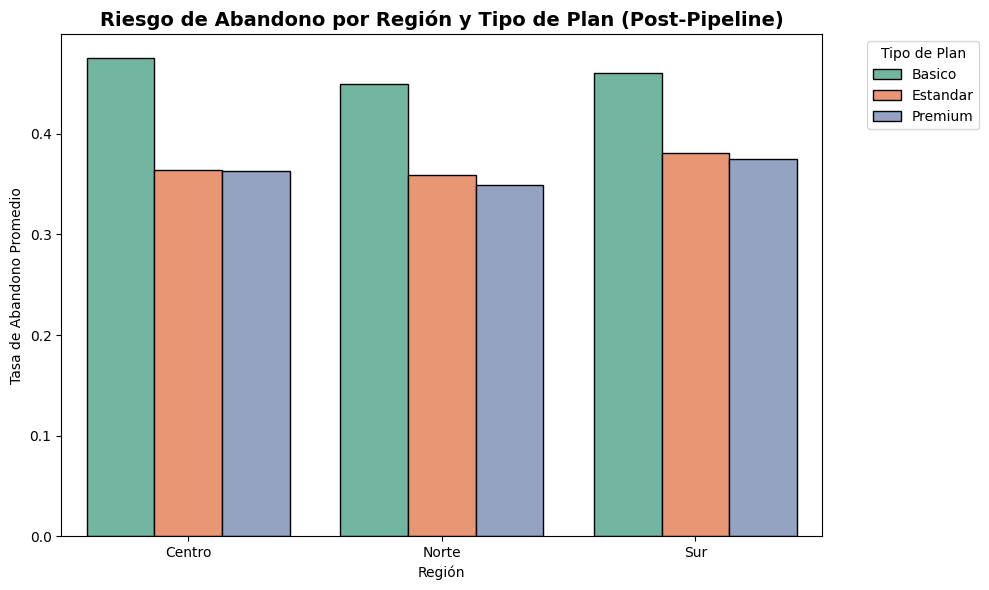

In [ ]:
def analisis_bivariado_region_clean(df):
    """
    Calcula la tasa de abandono y el gasto promedio agrupado por región y tipo de plan,
    utilizando las variables categóricas reconstruidas tras el preprocesamiento.

    Esta función agrupa los datos para identificar qué combinaciones geográficas
    y de servicio presentan un mayor riesgo de fuga (Churn Rate), permitiendo
    al negocio priorizar estrategias de retención segmentadas.

    Parámetros:
    -----------
    df : pandas.DataFrame
        El conjunto de datos preparado para visualización, que debe incluir
        las columnas reconstruidas 'region' y 'tipo_plan_nom'.

    Retorna:
    --------
    pandas.DataFrame
        Tabla resumen con las medias de 'abandono' y 'gasto_mensual', ordenada
        por región y, dentro de cada región, de mayor a menor riesgo de abandono.
    """
    # Agrupamos con las variables reconstruidas
    resumen_grupos = df.groupby(['region', 'tipo_plan_nom'])[['abandono', 'gasto_mensual']].mean().reset_index()
    resumen_grupos = resumen_grupos.sort_values(by=['region', 'abandono'], ascending=[True, False])

    print("=== Análisis Bivariado Clean: Tasa de Abandono y Gasto Medio por Región y Plan ===")
    return resumen_grupos

# Guardamos el resultado
resumen_region_plan_clean = analisis_bivariado_region_clean(df_plot)
display(resumen_region_plan_clean)

# Generamos el gráfico
plt.figure(figsize=(10, 6))
sns.barplot(data=resumen_region_plan_clean, x='region', y='abandono', hue='tipo_plan_nom', palette='Set2', edgecolor='black')
plt.title('Riesgo de Abandono por Región y Tipo de Plan (Post-Pipeline)', fontsize=14, fontweight='bold')
plt.ylabel('Tasa de Abandono Promedio')
plt.xlabel('Región')
plt.legend(title='Tipo de Plan', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

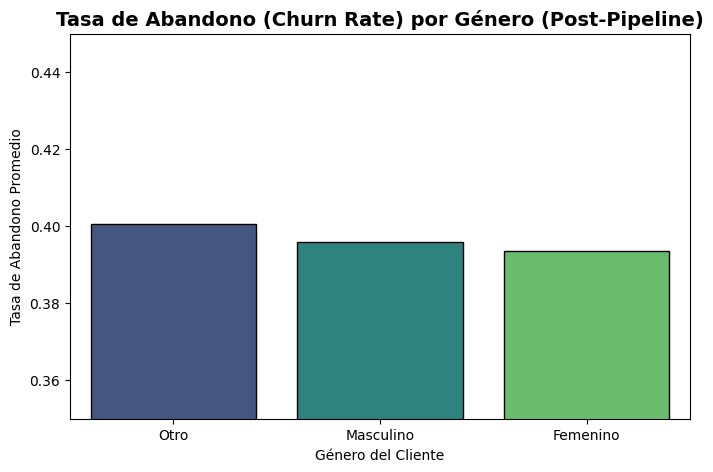

In [ ]:
def analisis_genero_abandono_clean(df):
    """
    Realiza un análisis exploratorio de la tasa de abandono y el gasto mensual
    promedio segmentado exclusivamente por el género del cliente.

    Permite identificar si un género específico tiene una mayor propensión
    a cancelar el servicio, lo que ayuda a evaluar si el producto, el contenido
    o las campañas de marketing están desalineados con algún segmento demográfico.

    Parámetros:
    -----------
    df : pandas.DataFrame
        El conjunto de datos preparado para visualización con la columna 'genero'
        ya reconstruida desde su formato One-Hot.

    Retorna:
    --------
    pandas.DataFrame
        Tabla resumen con las medias de 'abandono' y 'gasto_mensual' por género,
        ordenada de mayor a menor riesgo de abandono.
    """
    resumen_genero = df.groupby('genero')[['abandono', 'gasto_mensual']].mean().reset_index()
    resumen_genero = resumen_genero.sort_values(by='abandono', ascending=False)

    return resumen_genero

# Guardamos el resultado
resumen_genero_clean = analisis_genero_abandono_clean(df_plot)

# Generamos el gráfico solucionando el warning del hue
plt.figure(figsize=(8, 5))
sns.barplot(data=resumen_genero_clean, x='genero', y='abandono', hue='genero', palette='viridis', edgecolor='black')
plt.title('Tasa de Abandono (Churn Rate) por Género (Post-Pipeline)', fontsize=14, fontweight='bold')
plt.ylabel('Tasa de Abandono Promedio')
plt.xlabel('Género del Cliente')
plt.ylim(0.35, 0.45)
plt.show()


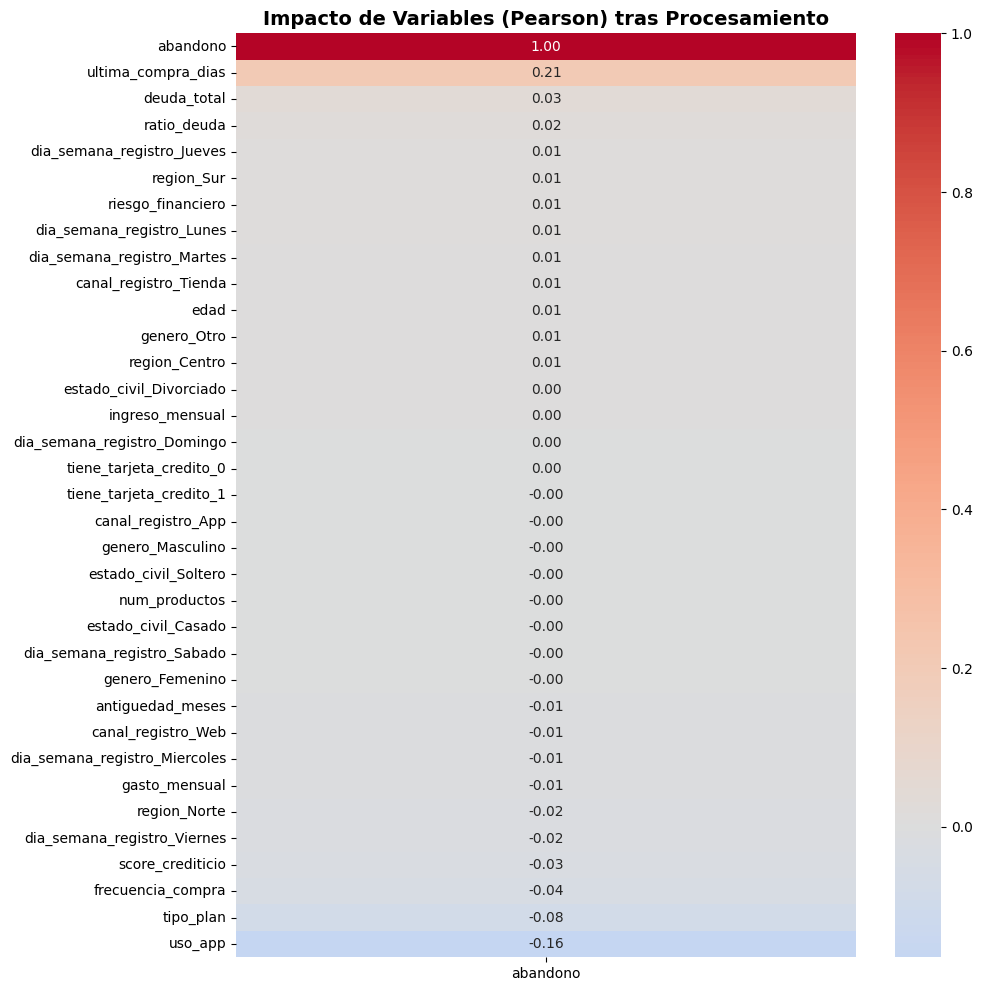

In [ ]:
def visualizar_impacto_negocio(data):
    """
    ANÁLISIS DE CORRELACIÓN DE PEARSON (DATA CLEAN)

    ¿POR QUÉ LOS RESULTADOS SON SIMILARES A SPEARMAN?

    1. Convergencia por Limpieza: La diferencia principal entre Pearson y Spearman
       es cómo manejan los valores extremos. Al haber procesado los datos con un
       'Winsorizer', hemos eliminado el ruido de los outliers.
       En una distribución sin extremos, Pearson y Spearman convergen hacia
       el mismo valor numérico.

    2. Validación del Pipeline: El hecho de que Pearson sea similar a Spearman
       valida que nuestro preprocesamiento fue exitoso; logramos una distribución
       lo suficientemente estable para que una medida lineal (Pearson) sea tan
       robusta como una medida de rangos (Spearman).

    3. Interpretación de la Señal: Si los valores siguen siendo bajos (~0.01),
       concluimos que el abandono no tiene una relación directa y simple con
       las variables individuales, lo que sugiere que se requieren modelos más
       complejos o análisis de interacciones para predecir el Churn.

    Retorna:
        Heatmap de Pearson sobre el DataFrame limpio.
    """
    # 1. Calculamos la matriz de correlación
    matriz_corr = data.corr()[['abandono']].sort_values(by='abandono', ascending=False)

    # 2. Configuramos el lienzo del gráfico
    plt.figure(figsize=(10, 12))

    # 3. Generamos el Mapa de Calor (Heatmap)
    sns.heatmap(matriz_corr, annot=True, cmap='coolwarm', fmt=".2f", center=0)

    plt.title("Impacto de Variables (Pearson) tras Procesamiento", fontsize=14, fontweight='bold')
    plt.show()

# Ejecutamos el análisis final
visualizar_impacto_negocio(data_clean)

Tras analizar ambas correlaciones basadas en la robustez de Spearman para el diagnóstico inicial de los datos crudos y la precisión lineal de Pearson para el conjunto de datos procesado, encontramos que no hay una razón exacta y simplista para entender el abandono del servicio debido a que los coeficientes obtenidos son cercanos a cero (rango de 0.01 a -0.02). Esta falta de correlación lineal fuerte se explica por los siguientes motivos técnicos y de negocio:

1) Multicausalidad del Churn: El abandono no está determinado por una sola variable aislada, como la deuda o la edad, sino por una combinación compleja de factores que no se manifiestan en una relación proporcional directa.

2) Efecto de la Limpieza de Datos: Aunque el Winsorizer y la imputación por media eliminaron el ruido de los valores extremos y nulos, también pudieron suavizar señales de comportamiento críticas presentes en los extremos de la distribución.

3) Relaciones No Lineales: La debilidad de los coeficientes sugiere que existen patrones no lineales o interacciones entre variables (por ejemplo, clientes con alto gasto pero baja antigüedad) que las métricas tradicionales de correlación no logran capturar.

4) Necesidad de Modelamiento Avanzado: Este hallazgo valida la necesidad de avanzar hacia modelos de Machine Learning (como árboles de decisión o bosques aleatorios), los cuales son capaces de detectar reglas de decisión complejas donde la estadística descriptiva tradicional no encuentra una señal clara.

En conclusión: Lejos de ser un error en el procesamiento, este resultado demuestra que el problema del abandono en la empresa es un fenómeno sofisticado. El valor de nuestro trabajo radica en haber limpiado el ruido técnico para confirmar que la estrategia de retención debe basarse en perfiles predictivos integrales y no en métricas aisladas.

# Revision CSV nuevo

In [ ]:
csv_nuevo = pd.read_csv('dataset_clientes_limpio.csv')
csv_nuevo

,edad,ingreso_mensual,gasto_mensual,deuda_total,score_crediticio,antiguedad_meses,frecuencia_compra,ultima_compra_dias,num_productos,ratio_deuda,...,dia_semana_registro_Martes,dia_semana_registro_Miercoles,dia_semana_registro_Sabado,dia_semana_registro_Viernes,tiene_tarjeta_credito_0,tiene_tarjeta_credito_1,uso_app,tipo_plan,riesgo_financiero,abandono
0,0.818182,0.638167,0.750001,0.648654,0.069273,0.886792,0.277778,1.000000,0.50,0.350003,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,1.0,1
1,0.545455,1.000000,0.328167,0.344409,0.426879,0.547170,0.388889,0.878049,0.75,0.082658,...,1.0,0.0,0.0,0.0,0.0,1.0,1.0,2.0,1.0,0
2,0.490909,0.496368,0.474789,1.000000,1.000000,0.000000,0.611111,0.649390,0.75,0.371217,...,0.0,0.0,0.0,0.0,0.0,1.0,2.0,2.0,0.0,0
3,0.600000,0.059194,0.535374,0.851296,0.031360,0.000000,0.111111,0.445122,0.25,1.000000,...,0.0,0.0,0.0,0.0,0.0,1.0,2.0,1.0,1.0,1
4,0.181818,0.420252,0.683403,0.350711,0.107477,0.066038,0.222222,0.804878,0.50,0.270779,...,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,1.0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19995,0.345455,0.827946,0.454569,0.373476,0.900207,0.792453,0.555556,0.957317,0.50,0.154541,...,0.0,0.0,0.0,0.0,0.0,1.0,2.0,0.0,1.0,1
19996,0.509091,0.716304,0.196729,0.448783,0.451902,0.481132,0.388889,0.966463,0.50,0.218873,...,0.0,1.0,0.0,0.0,1.0,0.0,0.0,2.0,1.0,1
19997,0.400000,0.496368,0.571591,0.813018,0.710751,0.896226,0.222222,0.423780,1.00,0.371217,...,1.0,0.0,0.0,0.0,0.0,1.0,0.0,2.0,0.0,0
19998,1.000000,0.310641,0.203465,0.574915,0.475218,0.915094,0.388889,0.679878,0.25,0.497706,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,1.0,0


In [ ]:
"""
PROPÓSITO:
Generar el archivo de dependencias 'requirements.txt' que documenta las versiones
exactas de todas las librerías utilizadas en este proyecto (Pandas, Scikit-Learn, etc.).

JUSTIFICACIÓN TÉCNICA (REPRODUCIBILIDAD):
Aunque el desarrollo se realiza en Google Colab, este comando permite exportar
el estado del entorno de ejecución. Esto garantiza que cualquier usuario pueda
replicar este análisis en un entorno local (Conda o venv) instalando las mismas
versiones, evitando errores de compatibilidad y asegurando la integridad de los
resultados del Pipeline de transformación.

"""

!pip freeze > requirements.txt
